In [22]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras kagglehub

# Neural Network Classification of Chest X-Rays
### Guido Di Santo

This project compares a CNN with `Flatten`, a CNN with `GlobalAveragePooling2D`,
and a pretrained MobileNetV2 to distinguish **NORMAL (0)** from **PNEUMONIA (1)**.
The notebook presents the dataset, experimental protocol, architectures, and
code for training and evaluating the models, including component comparisons
and error analysis.

1. [Objective and protocol](#introduction)
2. [Dataset and leakage checks](#dataset)
3. [Stratified group splitting](#split)
4. [Preprocessing and class weights](#preprocessing)
5. [CNNs and transfer learning](#models)
6. [Controlled experiments](#experiments)
7. [Threshold selection on the validation set](#threshold)
8. [Final evaluation and confidence intervals](#evaluation)
9. [Error analysis and conclusions](#conclusions)

**Running the notebook:** restart the kernel and execute the cells in order.
The full training procedure includes five experiments when `RUN_ABLATIONS=True`;
it takes time and downloads the ImageNet weights if they are not already cached.
Tables, plots, and quantitative conclusions are generated by the code cells
during execution. Dependencies are described in the environment section.

<a id="introduction"></a>
## 1. Objective and protocol

The objective is to investigate binary classification of pediatric chest X-rays
from the *Chest X-Ray Images (Pneumonia)* dataset. This is a machine learning
experiment: this test does not establish diagnostic effectiveness in other
hospitals or populations.

The protocol assigns three distinct roles: **training** to learn the weights,
**validation** for early stopping, model comparison, and threshold selection,
and **testing** to measure the performance of configurations that have already
been fixed. The educational constraint `TARGET_RECALL=0.98` is set before
evaluation; it is neither a validated clinical requirement nor a guarantee of
future sensitivity.

The decision threshold is the cutoff at or above which a score is assigned
to the PNEUMONIA class. Since this choice affects sensitivity and specificity,
it must be determined on the validation set alongside model selection.
The code then applies the fixed configurations to the test set, without searching
for a better threshold using the test labels.

The evaluation is exploratory and internal to this dataset. Generalization to
other settings requires external validation on data from different sources,
excluded from model development and selection.

Comparisons between CNN variants change one component at a time and use the
same data partitions; MobileNetV2 evaluates a transfer learning strategy.
A single seed provides an exploratory comparison. Assessing stability across
initializations requires repetitions of the full protocol, planned before
test-set evaluation.

In [23]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import gc
import re
import json
import hashlib
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
import tensorflow as tf
import kagglehub
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

SEED = 123
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
TARGET_RECALL = 0.98
MAX_EPOCHS = 25
HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 15
BOOTSTRAP_REPEATS = 1000
RUN_ABLATIONS = True
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
AUTOTUNE = tf.data.AUTOTUNE
ARTIFACT_DIR = Path("artifacts/progetto")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
environment = {name: version(name) for name in
               ["tensorflow", "keras", "numpy", "pandas", "scikit-learn", "kagglehub"]}
display(pd.Series(environment, name="version").to_frame())
(ARTIFACT_DIR / "environment.json").write_text(json.dumps(environment, indent=2))

,version
tensorflow,2.21.0
keras,3.15.1
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
kagglehub,1.0.2


141

The seed controls initialization, shuffling, and augmentation. Deterministic
operations improve repeatability but may slow down training. Different software
versions and hardware can still produce different results. The actual software
versions are saved alongside the experiments.

**Compatibility:** TensorFlow 2.17 requires NumPy below version 2. If imports
fail with ABI errors such as `_ARRAY_API` or `numpy.core.umath`, use a compatible
environment and restart the kernel; this is not a model error.

`requirements-progetto.txt` specifies the dependencies for Python 3.12.
The table generated by the configuration cell shows the actual versions in the
current environment. To reproduce the experiment, install the dependencies in
a dedicated virtual environment and select it as the notebook kernel.
The project metrics require full execution of the training and evaluation cells.

<a id="dataset"></a>
## 2. Dataset and leakage checks

The dataset is distributed on [Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
and contains `train`, `val`, and `test` folders, each with the two classes.
The original validation folder is not used because it contains only 16 images;
the validation set is therefore derived exclusively from the `train` folder.
The dataset version is pinned to **2**.

Before splitting the data, we build a manifest containing each image's path,
label, dimensions, decoded-pixel hash, and filename-derived group. The hash
identifies images that are exactly identical after conversion to grayscale,
even if their JPEG metadata differ. **It does not detect all near-duplicates**,
such as recompressed images with different pixels, rotated images, or crops.

For filenames such as `person123_bacteria_...` and `person123_virus_...`, we group
images sharing the `person123` prefix. For normal images, we group by `IM-xxxx`
or `NORMAL2-IM-xxxx`. These are **identifiers inferred from filenames**, not
verified clinical identifiers. The prefix is retained to distinguish the two
normal-image series. Unrecognized names stop the procedure and require review.

Groups and hashes are merged into connected components: if two images share
a filename group **or** identical content, they remain in the same partition,
including when the relationship is transitive. Development-set components
linked to the test set are excluded from development, leaving the test set
unchanged. This decision uses file identity and content only, not predictions.

In [24]:
def filename_group(path):
    stem = Path(path).stem
    match = re.match(r"^(person\d+)_", stem)
    if match:
        return "PNEUMONIA:" + match.group(1)
    match = re.match(r"^((?:NORMAL2-)?IM-\d+)-", stem)
    if match:
        return "NORMAL:" + match.group(1)
    raise ValueError(f"Filename without a recognizable group: {path}")


def image_record(path, split, label):
    with Image.open(path) as image:
        image = image.convert("L")
        width, height = image.size
        digest = hashlib.sha256(
            f"{width}x{height}:L:".encode() + image.tobytes()
        ).hexdigest()
    return dict(path=str(path.resolve()), original_split=split, label=label,
                class_name=CLASS_NAMES[label], filename_group=filename_group(path),
                pixel_hash=digest, width=width, height=height)


def connected_groups(frame):
    frame = frame.reset_index(drop=True).copy()
    parents = list(range(len(frame)))

    def find(i):
        while parents[i] != i:
            parents[i] = parents[parents[i]]
            i = parents[i]
        return i

    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj:
            parents[max(ri, rj)] = min(ri, rj)

    for column in ["filename_group", "pixel_hash"]:
        for indices in frame.groupby(column, sort=True).indices.values():
            for i in indices[1:]:
                union(int(indices[0]), int(i))
    frame["group"] = [f"group_{find(i):05d}" for i in range(len(frame))]
    return frame

In [25]:
dataset_path = Path(kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia/versions/2"
))
data_dir = dataset_path / "chest_xray"
records = []
for split in ["train", "val", "test"]:
    for label, name in enumerate(CLASS_NAMES):
        paths = sorted(p for p in (data_dir / split / name).iterdir()
                       if p.suffix.lower() in {".jpeg", ".jpg", ".png"})
        if not paths:
            raise ValueError(f"No images in {split}/{name}")
        records.extend(image_record(p, split, label) for p in paths)
manifest = connected_groups(pd.DataFrame(records))
assert manifest.path.is_unique

conflicting = manifest.groupby("pixel_hash").label.nunique()
if (conflicting > 1).any():
    raise ValueError("Identical images with conflicting labels: review the dataset.")

display(pd.crosstab(manifest.original_split, manifest.class_name)
        .reindex(index=["train", "val", "test"], columns=CLASS_NAMES))
duplicate_rows = manifest[manifest.duplicated("pixel_hash", keep=False)]
display(Markdown(f"Images belonging to exact-duplicate sets: **{len(duplicate_rows)}**."))
duplicate_rows.to_csv(ARTIFACT_DIR / "exact_duplicates.csv", index=False)

test_df = manifest[manifest.original_split.eq("test")].copy()
development = manifest[manifest.original_split.eq("train")].copy()
overlap_summary = pd.DataFrame({
    "criterion": ["same filename-derived identifier", "same pixel hash",
                 "same connected component"],
    "training_images_linked_to_test": [
        int(development.filename_group.isin(test_df.filename_group).sum()),
        int(development.pixel_hash.isin(test_df.pixel_hash).sum()),
        int(development.group.isin(test_df.group).sum()),
    ],
})
display(overlap_summary)
overlap_summary.to_csv(ARTIFACT_DIR / "train_test_overlap_audit.csv", index=False)
touches_test = development.group.isin(test_df.group)
quarantine = development[touches_test].copy()
development = development[~touches_test].copy()

# One copy per unique image in development; no removals from the official test set.
development_duplicates = development[development.duplicated("pixel_hash")].copy()
development = development.drop_duplicates("pixel_hash").reset_index(drop=True)
quarantine.to_csv(ARTIFACT_DIR / "excluded_test_overlap.csv", index=False)
development_duplicates.to_csv(ARTIFACT_DIR / "removed_development_duplicates.csv", index=False)
manifest.to_csv(ARTIFACT_DIR / "manifest.csv", index=False)
print(f"Excluded from development due to overlap with the test set: {len(quarantine)}")
print(f"Additional exact copies removed from development: {len(development_duplicates)}")
print(f"Unused original validation images: {sum(manifest.original_split.eq('val'))}")
print(f"Retained test images belonging to exact-duplicate sets: "
      f"{int(test_df.duplicated('pixel_hash', keep=False).sum())}")

class_name,NORMAL,PNEUMONIA
original_split,,
train,1341,3875
val,8,8
test,234,390


Images belonging to exact-duplicate sets: **62**.

,criterion,training_images_linked_to_test
0,same filename-derived identifier,457
1,same pixel hash,0
2,same connected component,457


Excluded from development due to overlap with the test set: 457
Additional exact copies removed from development: 22
Unused original validation images: 16
Retained test images belonging to exact-duplicate sets: 12


<a id="split"></a>
## 3. Stratified group splitting

`StratifiedGroupKFold` creates five candidate partitions with disjoint groups,
while attempting to preserve the class distribution. We select the fold closest
to 20% of the data and to the development-set prevalence, **without using model
performance**. Since groups cannot be divided, the proportions can only be
approximated. The actual file paths are saved so the comparison can be repeated.

Assertions separately check paths, groups, and hashes across every pair of
partitions. Separation is guaranteed with respect to these identifiers;
the lack of clinical metadata prevents an absolute patient-level guarantee.

In [26]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
candidates = list(splitter.split(development.path, development.label, development.group))
prevalence = development.label.mean()

def split_cost(pair):
    _, val_indices = pair
    val = development.iloc[val_indices]
    return abs(len(val) / len(development) - 0.2) + abs(val.label.mean() - prevalence)

train_indices, val_indices = min(candidates, key=split_cost)
train_df = development.iloc[train_indices].sort_values("path").reset_index(drop=True)
val_df = development.iloc[val_indices].sort_values("path").reset_index(drop=True)
test_df = test_df.sort_values("path").reset_index(drop=True)

partitions = {"train": train_df, "validation": val_df, "test": test_df}
for name, frame in partitions.items():
    assert set(frame.label) == {0, 1}, f"Missing class in {name}"
    frame.to_csv(ARTIFACT_DIR / f"{name}_split.csv", index=False)
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    for column in ["path", "group", "pixel_hash"]:
        assert set(partitions[a][column]).isdisjoint(partitions[b][column]), (a, b, column)

split_summary = pd.DataFrame([
    {"split": name, "images": len(frame), "groups": frame.group.nunique(),
     "NORMAL": int(frame.label.eq(0).sum()), "PNEUMONIA": int(frame.label.eq(1).sum()),
     "% PNEUMONIA": 100 * frame.label.mean()}
    for name, frame in partitions.items()
]).set_index("split")
display(split_summary.round(2))
display(pd.concat([frame.assign(split=name) for name, frame in partitions.items()])
        .assign(aspect_ratio=lambda x: x.width / x.height)
        .groupby("split")[["width", "height", "aspect_ratio"]].agg(["median", "min", "max"]))

,images,groups,NORMAL,PNEUMONIA,% PNEUMONIA
split,,,,,
train,3790,2141,1072,2718,71.72
validation,947,535,268,679,71.70
test,624,426,234,390,62.50


width            height            aspect_ratio            \
            median  min   max median  min   max       median       min   
split                                                                    
test        1265.0  728  2752  870.5  344  2713     1.452314  0.927755   
train       1304.0  384  2916  904.0  127  2663     1.403385  0.835391   
validation  1288.0  400  2694  904.0  132  2625     1.415929  0.915319   

                      
                 max  
split                 
test        2.581395  
train       3.271523  
validation  3.378788

<a id="preprocessing"></a>
## 4. Preprocessing, augmentation, and class weights

The pipeline reads grayscale images in `[0, 255]`, resizes them while preserving
the aspect ratio, and adds padding to reach 180×180. This avoids distorting the
chest; however, padding is a potential spurious cue to consider during error
analysis. All models use the same image format.

Normalization is applied **inside the model**, exactly once: `[0, 1]` for the
CNNs and `[-1, 1]` for MobileNetV2. For MobileNetV2, the grayscale channel is
replicated three times. The original datasets are not overwritten with cumulative
transformations; validation and test samples retain a fixed order.

Training augmentation includes small rotations, zoom changes, and contrast
adjustments. Horizontal flipping is omitted to preserve laterality. Examples
of the transformations are displayed, and their usefulness is evaluated
experimentally rather than assumed. Random augmentation layers inside the
model are disabled during inference.

Weights are computed **using training labels only**:
\(w_c=N/(K N_c)\). They balance the contribution of each class to the loss;
they do not estimate the clinical cost of errors. They may change the learned
scores, but do not set the decision threshold. A sigmoid output, particularly
after weighted training, is not automatically a calibrated probability.

NORMAL       1.767724
PNEUMONIA    0.697204
Name: loss weight, dtype: float64

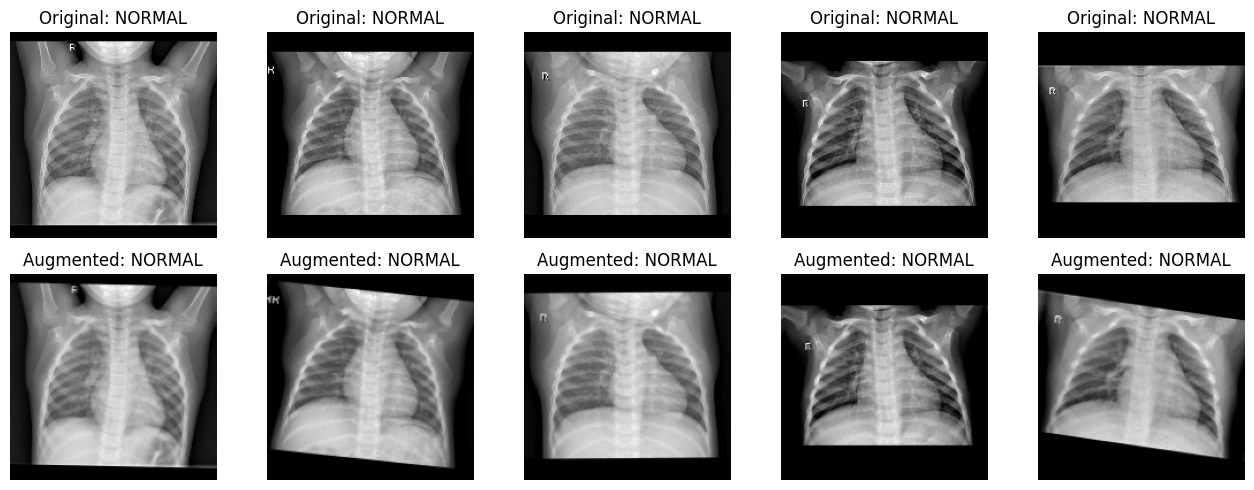

In [27]:
def read_image(path, label):
    image = tf.io.decode_image(tf.io.read_file(path), channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize_with_pad(tf.cast(image, tf.float32), *IMG_SIZE)
    image = tf.ensure_shape(image, (*IMG_SIZE, 1))
    return image, tf.reshape(tf.cast(label, tf.float32), [1])


def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame.path.to_numpy(), frame.label.to_numpy(dtype=np.int32)))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(read_image, num_parallel_calls=AUTOTUNE, deterministic=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.025, seed=SEED + 1),
        tf.keras.layers.RandomZoom(0.05, seed=SEED + 2),
        tf.keras.layers.RandomContrast(0.1, seed=SEED + 3),
    ], name="augmentation")


weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]),
                               y=train_df.label.to_numpy())
class_weights = dict(zip([0, 1], map(float, weights)))
display(pd.Series(class_weights, name="loss weight").rename(index=dict(enumerate(CLASS_NAMES))))
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

images, labels = next(iter(make_dataset(train_df).take(1)))
assert images.shape[1:] == (*IMG_SIZE, 1)
assert float(tf.reduce_min(images)) >= 0 and float(tf.reduce_max(images)) <= 255
augmented = augmentation()(images, training=True)
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i in range(min(5, len(images))):
    for row, batch in enumerate([images, augmented]):
        axes[row, i].imshow(batch[i].numpy().squeeze(), cmap="gray", vmin=0, vmax=255)
        axes[row, i].set_title(("Original: " if row == 0 else "Augmented: ")
                               + CLASS_NAMES[int(labels[i, 0])])
        axes[row, i].axis("off")
plt.tight_layout()
plt.show()

<a id="models"></a>
## 5. Architectures: CNNs with Flatten and Global Average Pooling

Both CNNs share three `Conv2D → BatchNormalization → ReLU → MaxPooling → Dropout`
blocks, with 32, 64, and 128 filters. BatchNormalization normalizes activations
during training and uses accumulated statistics during inference; it does not
by itself prevent overfitting. Dropout and pooling must also be evaluated on
the validation set.

In the Flatten CNN, `Flatten` converts the 22×22×128 feature map into 61,952
features. The subsequent `Dense(128)` layer has **7,929,984 parameters**, out
of **8,024,193** in total. This layer accounts for approximately 98.8% of the
model's parameters, motivating a comparison with a smaller classifier head.

The alternative replaces only `Flatten` with `GlobalAveragePooling2D`, which
computes a spatial average for each channel and returns 128 features. Keeping
the remaining layers unchanged gives **110,721 parameters**. This is a hypothesis
to test: the classifier head has lower capacity, but spatial information is lost.
Improved accuracy or generalization is not assumed.

In [28]:
def build_cnn(pooling="gap", use_augmentation=True):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 1), name="radiografia_0_255")
    x = augmentation()(inputs) if use_augmentation else inputs
    x = tf.keras.layers.Rescaling(1.0 / 255, name="normalizzazione_cnn")(x)
    for filters, dropout in [(32, 0.2), (64, 0.3), (128, 0.4)]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPooling2D(2)(x)
        x = tf.keras.layers.Dropout(dropout)(x)
    if pooling == "flatten":
        x = tf.keras.layers.Flatten()(x)
    elif pooling == "gap":
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
    else:
        raise ValueError(pooling)
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name=f"cnn_{pooling}")


parameter_table = []
for pooling in ["flatten", "gap"]:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    example = build_cnn(pooling)
    parameter_table.append({"model": example.name, "parameters": example.count_params()})
display(pd.DataFrame(parameter_table).set_index("model"))
assert parameter_table[0]["parameters"] == 8024193
assert parameter_table[1]["parameters"] == 110721
del example

,parameters
model,
cnn_flatten,8024193
cnn_gap,110721


### MobileNetV2: preprocessing and two-stage training

MobileNetV2 uses weights pretrained on ImageNet and requires inputs in `[-1, 1]`.
The model receives pixels in `[0, 255]`, replicates the grayscale channel, and
uses `Rescaling(1/127.5, offset=-1)`, equivalent to the preprocessing required by
[MobileNetV2](https://keras.io/api/applications/mobilenet/mobilenet_models/).
A resolution of 180×180 is valid with `include_top=False`; the available weights
come from training at 224×224, which Keras may report in a warning.

In the first stage, the ImageNet base is frozen and only the classifier head
is trained. In the second, the final 30 layers are unfrozen, except for
BatchNormalization layers, and the model is recompiled with a learning rate of
`1e-5`. The base is called with `training=False`, keeping normalization statistics
fixed during fine-tuning. The better model from the two stages is retained
based on validation loss, since fine-tuning may also worsen performance.
This follows the [Keras transfer learning guide](https://keras.io/guides/transfer_learning/).

In [29]:
def build_mobilenet(weights="imagenet"):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 1), name="radiografia_0_255")
    x = augmentation()(inputs)
    x = tf.keras.layers.Concatenate(name="grayscale_to_rgb")([x, x, x])
    x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1,
                                name="normalizzazione_mobilenet")(x)
    base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3), include_top=False, weights=weights, pooling="avg")
    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="mobilenet_v2"), base


def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                 tf.keras.metrics.AUC(name="roc_auc"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.Precision(name="precision")])


def training_callbacks():
    return [
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=2, min_lr=1e-7),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                        restore_best_weights=True),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

<a id="experiments"></a>
## 6. Controlled experiments and training

The three main comparisons are CNN-Flatten, CNN-GAP, and MobileNetV2. Two optional
ablations, enabled by default, remove **augmentation only** or **class weights
only** from CNN-GAP. All other settings in the CNN comparison remain unchanged:
splits, preprocessing, seed, optimizer, and early stopping rule. The actual
number of epochs may differ under the same stopping rule.

The Flatten/GAP comparison isolates the pooling choice; the other ablations
evaluate their respective components in the presence of the remaining ones.
MobileNet evaluates a different overall strategy, with pretraining and two
training stages, rather than isolating architecture alone. The number of
convolutional blocks remains fixed: the comparisons concern pooling,
augmentation, class weights, and the transfer learning strategy.

Early stopping monitors validation loss and restores the best weights.
Weighted training loss and unweighted validation loss **are not directly
comparable**; augmentation and dropout also create different training and
inference conditions. The curves help diagnose learning but do not, on their
own, establish the benefit of a technique.

No test-set predictions are made during this stage. Models, training histories,
and configurations are saved in `artifacts/progetto`.

In [30]:
EXPERIMENTS = [
    dict(name="cnn_flatten", family="cnn", pooling="flatten", augmentation=True, weighted=True),
    dict(name="cnn_gap", family="cnn", pooling="gap", augmentation=True, weighted=True),
    dict(name="mobilenet_v2", family="mobilenet", augmentation=True, weighted=True),
]
if RUN_ABLATIONS:
    EXPERIMENTS += [
        dict(name="cnn_gap_no_augmentation", family="cnn", pooling="gap", augmentation=False, weighted=True),
        dict(name="cnn_gap_no_weights", family="cnn", pooling="gap", augmentation=True, weighted=False),
    ]
display(pd.DataFrame(EXPERIMENTS).set_index("name"))


def fit_experiment(config):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    training = make_dataset(train_df, training=True)
    kwargs = dict(validation_data=val_ds, callbacks=training_callbacks(),
                  class_weight=class_weights if config["weighted"] else None, verbose=2)
    histories = {}
    selected_phase = "cnn"

    if config["family"] == "cnn":
        model = build_cnn(config["pooling"], config["augmentation"])
        compile_model(model, 1e-3)
        histories["cnn"] = model.fit(training, epochs=MAX_EPOCHS, **kwargs).history
    else:
        model, base = build_mobilenet()
        compile_model(model, 1e-3)
        histories["head"] = model.fit(training, epochs=HEAD_EPOCHS, **kwargs).history
        head_path = ARTIFACT_DIR / f"{config['name']}_head.weights.h5"
        model.save_weights(head_path)
        head_loss = model.evaluate(val_ds, verbose=0, return_dict=True)["loss"]

        base.trainable = True
        for layer in base.layers:
            layer.trainable = False
        for layer in base.layers[-30:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True
        compile_model(model, 1e-5)
        kwargs["callbacks"] = training_callbacks()
        histories["fine_tune"] = model.fit(training, epochs=FINE_TUNE_EPOCHS, **kwargs).history
        fine_loss = model.evaluate(val_ds, verbose=0, return_dict=True)["loss"]
        selected_phase = "fine_tune"
        if head_loss <= fine_loss:
            model.load_weights(head_path)
            selected_phase = "head"

    scores = model.predict(val_ds, verbose=0).ravel()
    assert len(scores) == len(val_df) and np.isfinite(scores).all()
    path = ARTIFACT_DIR / f"{config['name']}.keras"
    model.save(path)
    result = dict(config=config, model_path=str(path), params=model.count_params(),
                  histories=histories, selected_phase=selected_phase,
                  val_scores=scores, val_loss=float(model.evaluate(
                      val_ds, verbose=0, return_dict=True)["loss"]))
    serializable = {key: value for key, value in result.items() if key != "val_scores"}
    (ARTIFACT_DIR / f"{config['name']}_training.json").write_text(
        json.dumps(serializable, indent=2))
    np.save(ARTIFACT_DIR / f"{config['name']}_val_scores.npy", scores)
    del model
    gc.collect()
    return result

,family,pooling,augmentation,weighted
name,,,,
cnn_flatten,cnn,flatten,True,True
cnn_gap,cnn,gap,True,True
mobilenet_v2,mobilenet,NaN,True,True
cnn_gap_no_augmentation,cnn,gap,False,True
cnn_gap_no_weights,cnn,gap,True,False


In [31]:
runs = {}
for config in EXPERIMENTS:
    print(f"\nExperiment: {config['name']}")
    runs[config["name"]] = fit_experiment(config)


Experiment: cnn_flatten
Epoch 1/25


/Users/guidodisanto/miniconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 - 301s - 3s/step - accuracy: 0.8995 - loss: 0.2387 - precision: 0.9650 - recall: 0.8922 - roc_auc: 0.9656 - val_accuracy: 0.7170 - val_loss: 0.6461 - val_precision: 0.7170 - val_recall: 1.0000 - val_roc_auc: 0.9445 - learning_rate: 0.0010
Epoch 2/25
119/119 - 320s - 3s/step - accuracy: 0.9383 - loss: 0.1492 - precision: 0.9814 - recall: 0.9316 - roc_auc: 0.9860 - val_accuracy: 0.7170 - val_loss: 0.5295 - val_precision: 0.7170 - val_recall: 1.0000 - val_roc_auc: 0.9675 - learning_rate: 0.0010
Epoch 3/25
119/119 - 222s - 2s/step - accuracy: 0.9470 - loss: 0.1311 - precision: 0.9824 - recall: 0.9430 - roc_auc: 0.9887 - val_accuracy: 0.8669 - val_loss: 0.3079 - val_precision: 0.8443 - val_recall: 0.9985 - val_roc_auc: 0.9865 - learning_rate: 0.0010
Epoch 4/25
119/119 - 260s - 2s/step - accuracy: 0.9557 - loss: 0.1148 - precision: 0.9874 - recall: 0.9503 - roc_auc: 0.9911 - val_accuracy: 0.7592 - val_loss: 0.4091 - val_precision: 0.7486 - val_recall: 1.0000 - val_roc_auc: 0.9854 - l

/var/folders/jm/brl1kdcn5mv6s_f18tvp6lsh0000gn/T/ipykernel_90446/1654333398.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Epoch 1/10
119/119 - 75s - 631ms/step - accuracy: 0.8464 - loss: 0.3396 - precision: 0.9421 - recall: 0.8374 - roc_auc: 0.9280 - val_accuracy: 0.9377 - val_loss: 0.1664 - val_precision: 0.9506 - val_recall: 0.9632 - val_roc_auc: 0.9791 - learning_rate: 0.0010
Epoch 2/10
119/119 - 65s - 542ms/step - accuracy: 0.9119 - loss: 0.2174 - precision: 0.9715 - recall: 0.9036 - roc_auc: 0.9712 - val_accuracy: 0.9461 - val_loss: 0.1370 - val_precision: 0.9729 - val_recall: 0.9514 - val_roc_auc: 0.9865 - learning_rate: 0.0010
Epoch 3/10
119/119 - 59s - 492ms/step - accuracy: 0.9187 - loss: 0.1935 - precision: 0.9752 - recall: 0.9099 - roc_auc: 0.9777 - val_accuracy: 0.9493 - val_loss: 0.1313 - val_precision: 0.9832 - val_recall: 0.9455 - val_roc_auc: 0.9891 - learning_rate: 0.0010
Epoch 4/10
119/119 - 65s - 547ms/step - accuracy: 0.9282 - loss: 0.1774 - precision: 0.9759 - recall: 0.9227 - roc_auc: 0.9809 - val_accuracy: 0.9440 - val_loss: 0.1328 - val_precision: 0.9845 - val_recall: 0.9367 - val_

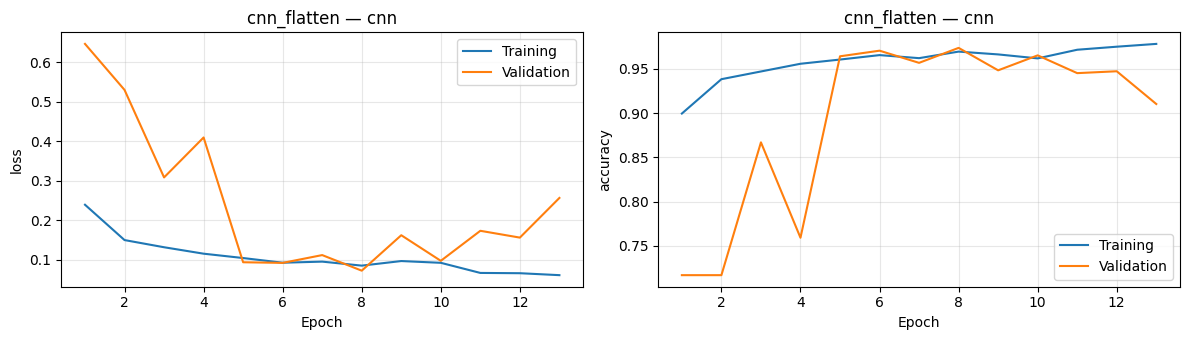

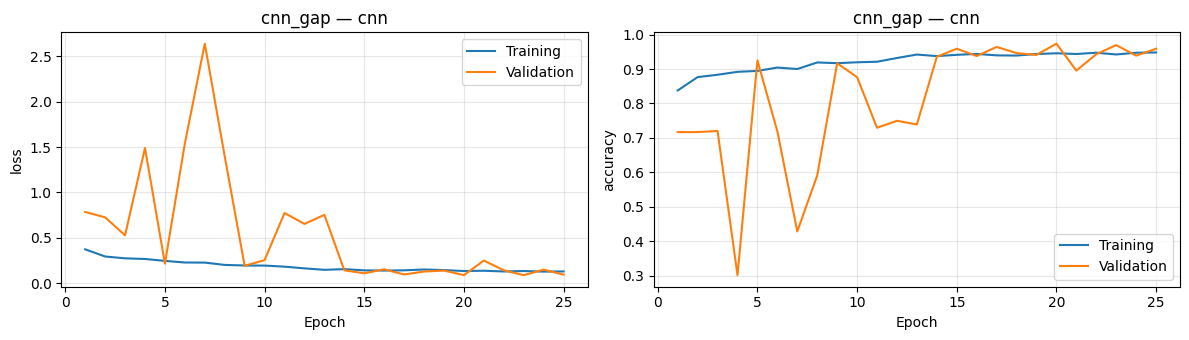

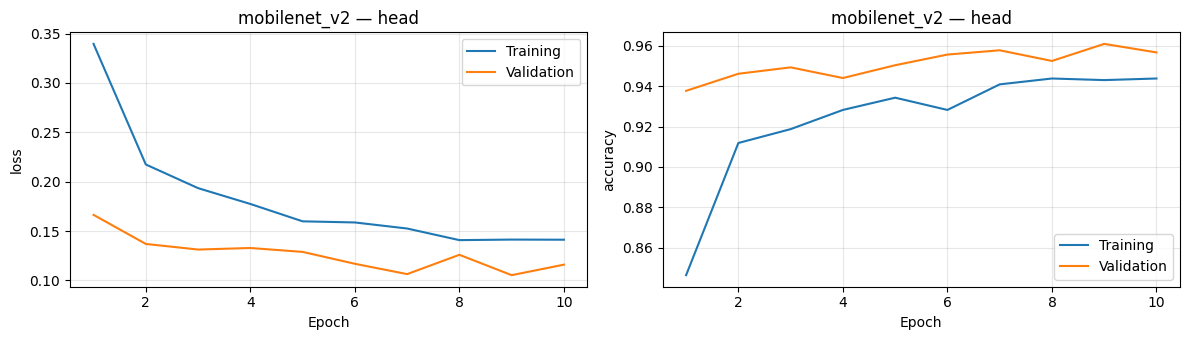

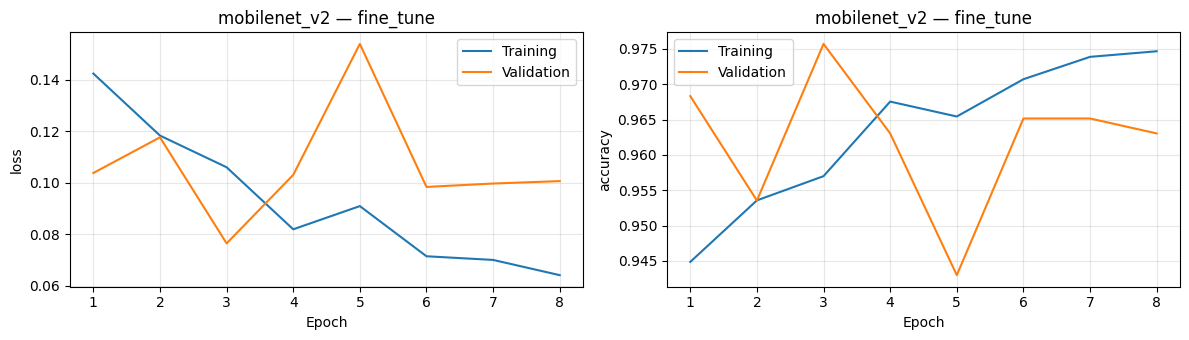

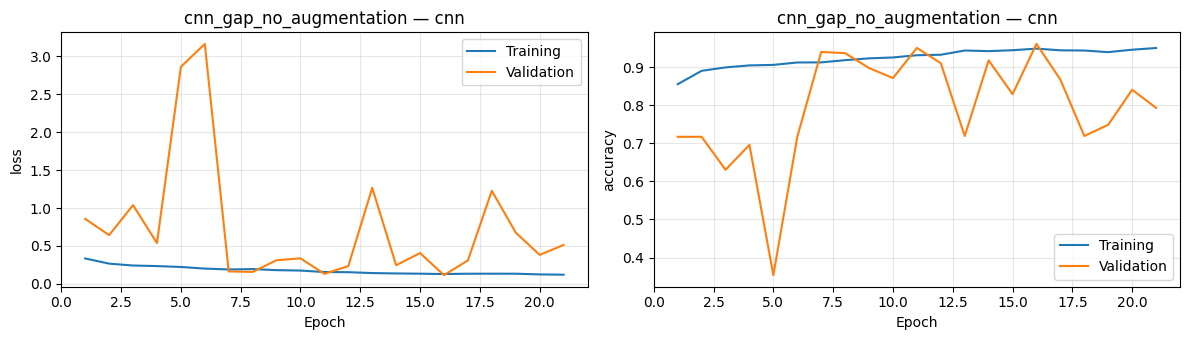

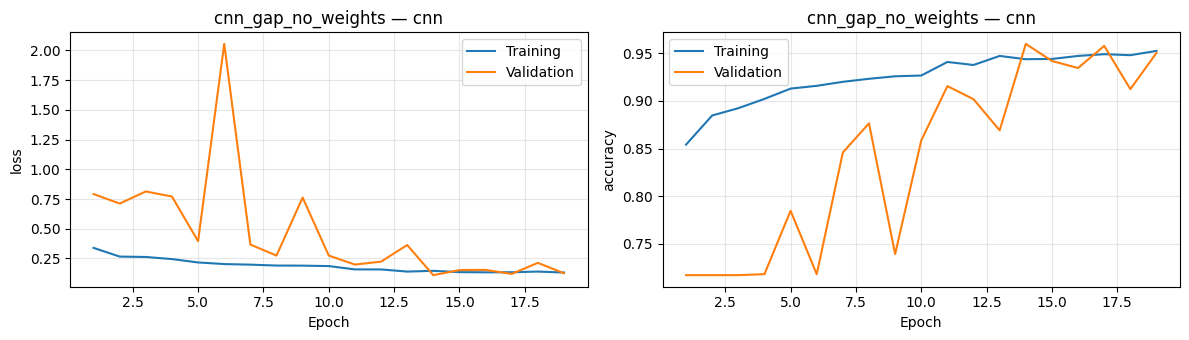

In [32]:
for name, run in runs.items():
    for phase, history in run["histories"].items():
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
        epochs = np.arange(1, len(history["loss"]) + 1)
        for ax, metric in zip(axes, ["loss", "accuracy"]):
            ax.plot(epochs, history[metric], label="Training")
            ax.plot(epochs, history[f"val_{metric}"], label="Validation")
            ax.set(xlabel="Epoch", ylabel=metric, title=f"{name} — {phase}")
            ax.legend()
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

<a id="threshold"></a>
## 7. Threshold selection using the validation set only

Scores are converted to labels using `score >= threshold`. For each model, we
search the validation set for the threshold achieving recall of at least 0.98
with the lowest FPR; ties are resolved by selecting the highest threshold.
A threshold of 0.5 is also evaluated as a reference. Scores are computed in
batches once per model.

The threshold is stored at full precision and rounded only for display.
The ROC curve includes every point (`drop_intermediate=False`). The constraint
is empirical: 98% validation recall does not guarantee 98% recall on the test
set or on new patients. Increasing the threshold can reduce both false positives
and true positives; this trade-off must be quantified rather than automatically
interpreted as an improvement.

Before using the test set, we also select the primary model: highest validation
specificity at the constrained threshold, followed by ROC-AUC and then fewer
parameters. This predefined rule uses validation data only. Selection makes
validation metrics optimistic; the test set serves a different purpose.
Reference: [scikit-learn, threshold tuning](https://scikit-learn.org/stable/modules/classification_threshold.html).

In [33]:
def metric_values(y_true, scores, threshold):
    y_true = np.asarray(y_true).ravel().astype(int)
    scores = np.asarray(scores).ravel()
    predicted = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    ratio = lambda a, b: float(a / b) if b else np.nan
    sensitivity = ratio(tp, tp + fn)
    specificity = ratio(tn, tn + fp)
    two_classes = np.unique(y_true).size == 2
    return {
        "accuracy": ratio(tp + tn, len(y_true)), "sensitivity": sensitivity,
        "specificity": specificity, "precision": ratio(tp, tp + fp),
        "npv": ratio(tn, tn + fn), "f1": ratio(2 * tp, 2 * tp + fp + fn),
        "balanced_accuracy": (sensitivity + specificity) / 2,
        "roc_auc": float(roc_auc_score(y_true, scores)) if two_classes else np.nan,
        "average_precision": float(average_precision_score(y_true, scores)) if two_classes else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def choose_threshold(y_true, scores, target_recall=TARGET_RECALL):
    if not 0 < target_recall <= 1:
        raise ValueError("target_recall must be in (0, 1].")
    if np.unique(y_true).size != 2 or not np.isfinite(scores).all():
        raise ValueError("Two classes and finite scores are required.")
    fpr, tpr, thresholds = roc_curve(y_true, scores, drop_intermediate=False)
    eligible = np.flatnonzero((tpr >= target_recall) & np.isfinite(thresholds))
    best = min(eligible, key=lambda i: (fpr[i], -thresholds[i]))
    return float(thresholds[best])


validation_rows = []
for name, run in runs.items():
    run["threshold"] = choose_threshold(val_df.label, run["val_scores"])
    for operating_point, threshold in [("0.5", 0.5), ("validation", run["threshold"])]:
        validation_rows.append(dict(
            model=name, operating_point=operating_point, threshold=threshold,
            params=run["params"], loss=run["val_loss"],
            **metric_values(val_df.label, run["val_scores"], threshold)))

validation_results = pd.DataFrame(validation_rows)
ranking = validation_results.query("operating_point == 'validation'").sort_values(
    ["specificity", "roc_auc", "params", "model"], ascending=[False, False, True, True])
PRIMARY_MODEL = ranking.iloc[0]["model"]
display(validation_results.round(4))
print("Model selected BEFORE test evaluation:", PRIMARY_MODEL)
validation_results.to_csv(ARTIFACT_DIR / "validation_results.csv", index=False)

frozen_protocol = dict(
    seed=SEED, target_recall=TARGET_RECALL, primary_model=PRIMARY_MODEL,
    thresholds={name: run["threshold"] for name, run in runs.items()},
    experiments=EXPERIMENTS,
    selection_rule="validation specificity, then ROC-AUC, then fewer parameters",
    evaluation_scope="exploratory_within_dataset", external_validation=False)
(ARTIFACT_DIR / "frozen_protocol.json").write_text(json.dumps(frozen_protocol, indent=2))

,model,operating_point,threshold,params,loss,accuracy,sensitivity,specificity,precision,npv,f1,balanced_accuracy,roc_auc,average_precision,tn,fp,fn,tp
0,cnn_flatten,0.5,0.5000,8024193,0.0718,0.9736,0.9750,0.9701,0.9881,0.9386,0.9815,0.9726,0.9956,0.9982,260,8,17,662
1,cnn_flatten,validation,0.4323,8024193,0.0718,0.9757,0.9809,0.9627,0.9852,0.9520,0.9830,0.9718,0.9956,0.9982,258,10,13,666
2,cnn_gap,0.5,0.5000,110721,0.0891,0.9694,0.9750,0.9552,0.9822,0.9377,0.9786,0.9651,0.9943,0.9979,256,12,17,662
3,cnn_gap,validation,0.4531,110721,0.0891,0.9736,0.9809,0.9552,0.9823,0.9517,0.9816,0.9680,0.9943,0.9979,256,12,13,666
4,mobilenet_v2,0.5,0.5000,2259265,0.0765,0.9757,0.9794,0.9664,0.9866,0.9487,0.9830,0.9729,0.9958,0.9984,259,9,14,665
5,mobilenet_v2,validation,0.2853,2259265,0.0765,0.9694,0.9809,0.9403,0.9765,0.9509,0.9787,0.9606,0.9958,0.9984,252,16,13,666
6,cnn_gap_no_augmentation,0.5,0.5000,110721,0.1157,0.9609,0.9720,0.9328,0.9735,0.9294,0.9727,0.9524,0.9894,0.9959,250,18,19,660
7,cnn_gap_no_augmentation,validation,0.3960,110721,0.1157,0.9609,0.9809,0.9104,0.9652,0.9494,0.9730,0.9457,0.9894,0.9959,244,24,13,666
8,cnn_gap_no_weights,0.5,0.5000,110721,0.1099,0.9599,0.9661,0.9440,0.9776,0.9167,0.9719,0.9551,0.9908,0.9965,253,15,23,656
9,cnn_gap_no_weights,validation,0.3491,110721,0.1099,0.9641,0.9809,0.9216,0.9694,0.9500,0.9751,0.9512,0.9908,0.9965,247,21,13,666


Model selected BEFORE test evaluation: cnn_flatten


1205

<a id="evaluation"></a>
## 8. Final evaluation, baseline, and uncertainty

The test set is now processed using fixed models and thresholds. We report
accuracy, sensitivity, **specificity**, precision, negative predictive value,
F1, balanced accuracy, ROC-AUC, and **average precision (AP)**. AP summarizes
the precision-recall curve and depends on prevalence; it is not the same as
the trapezoidal area under the PR curve. The baseline always predicts the
majority class in the **training set**, selected without consulting the test set.

Specificity measures how many NORMAL images are correctly identified. High
recall accompanied by low specificity requires an explicit discussion of false
positives. Precision and NPV depend on the sample composition and do not
automatically transfer to populations with different prevalence.

The primary model's 95% intervals are estimated using a **group bootstrap**:
components defined during the audit are sampled with replacement, and all images
in each selected group are included. This preserves known dependencies and
exact duplicates, but does not account for unidentified clinical relationships.
Metrics remain image-level estimates. The model and threshold stay fixed in
every replicate: the intervals describe test-sample uncertainty, not uncertainty
in the entire training and selection process.

In [34]:
test_rows = []
test_scores = {}
for name, run in runs.items():
    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(run["model_path"], compile=False)
    scores = model.predict(test_ds, verbose=0).ravel()
    assert len(scores) == len(test_df) and np.isfinite(scores).all()
    test_scores[name] = scores
    for operating_point, threshold in [("0.5", 0.5), ("validation", run["threshold"])]:
        test_rows.append(dict(model=name, operating_point=operating_point,
                              threshold=threshold,
                              **metric_values(test_df.label, scores, threshold)))
    pd.DataFrame({"path": test_df.path, "group": test_df.group,
                  "label": test_df.label, "score": scores}).to_csv(
        ARTIFACT_DIR / f"{name}_test_predictions.csv", index=False)
    del model
    gc.collect()

majority_class = int(train_df.label.mode().iloc[0])
baseline_scores = np.full(len(test_df), float(majority_class))
test_rows.append(dict(model="baseline_majority", operating_point="0.5", threshold=0.5,
                      **metric_values(test_df.label, baseline_scores, 0.5)))
test_results = pd.DataFrame(test_rows)
display(test_results.round(4))
test_results.to_csv(ARTIFACT_DIR / "test_results.csv", index=False)

,model,operating_point,threshold,accuracy,sensitivity,specificity,precision,npv,f1,balanced_accuracy,roc_auc,average_precision,tn,fp,fn,tp
0,cnn_flatten,0.5,0.5000,0.8077,0.9949,0.4957,0.7668,0.9831,0.8661,0.7453,0.9575,0.9726,116,118,2,388
1,cnn_flatten,validation,0.4323,0.8029,0.9949,0.4829,0.7623,0.9826,0.8632,0.7389,0.9575,0.9726,113,121,2,388
2,cnn_gap,0.5,0.5000,0.8189,0.9821,0.5470,0.7832,0.9481,0.8714,0.7645,0.9479,0.9627,128,106,7,383
3,cnn_gap,validation,0.4531,0.8141,0.9872,0.5256,0.7762,0.9609,0.8691,0.7564,0.9479,0.9627,123,111,5,385
4,mobilenet_v2,0.5,0.5000,0.8109,0.9897,0.5128,0.7720,0.9677,0.8674,0.7513,0.9522,0.9666,120,114,4,386
5,mobilenet_v2,validation,0.2853,0.7853,0.9949,0.4359,0.7462,0.9808,0.8527,0.7154,0.9522,0.9666,102,132,2,388
6,cnn_gap_no_augmentation,0.5,0.5000,0.7564,0.9949,0.3590,0.7212,0.9767,0.8362,0.6769,0.9288,0.9479,84,150,2,388
7,cnn_gap_no_augmentation,validation,0.3960,0.7340,0.9949,0.2991,0.7029,0.9722,0.8238,0.6470,0.9288,0.9479,70,164,2,388
8,cnn_gap_no_weights,0.5,0.5000,0.8045,0.9846,0.5043,0.7680,0.9516,0.8629,0.7444,0.9377,0.9582,118,116,6,384
9,cnn_gap_no_weights,validation,0.3491,0.7660,0.9923,0.3889,0.7302,0.9681,0.8413,0.6906,0.9377,0.9582,91,143,3,387


In [35]:
def grouped_bootstrap_ci(y_true, scores, groups, threshold, repeats=BOOTSTRAP_REPEATS, seed=SEED):
    y_true, scores, groups = map(np.asarray, (y_true, scores, groups))
    unique_groups = np.unique(groups)
    indices = [np.flatnonzero(groups == group) for group in unique_groups]
    rng = np.random.default_rng(seed)
    point = metric_values(y_true, scores, threshold)
    metrics = [key for key in point if key not in {"tn", "fp", "fn", "tp"}]
    samples = {key: [] for key in metrics}
    for _ in range(repeats):
        selected = rng.integers(0, len(indices), size=len(indices))
        ix = np.concatenate([indices[i] for i in selected])
        estimate = metric_values(y_true[ix], scores[ix], threshold)
        for key in metrics:
            if np.isfinite(estimate[key]):
                samples[key].append(estimate[key])
    rows = []
    for key in metrics:
        values = samples[key]
        lower, upper = np.percentile(values, [2.5, 97.5]) if values else (np.nan, np.nan)
        rows.append(dict(metric=key, estimate=point[key], lower_95=lower, upper_95=upper,
                         valid_replicates=len(values)))
    return pd.DataFrame(rows).set_index("metric")


primary_scores = test_scores[PRIMARY_MODEL]
primary_threshold = runs[PRIMARY_MODEL]["threshold"]
confidence_intervals = grouped_bootstrap_ci(
    test_df.label, primary_scores, test_df.group, primary_threshold)
display(confidence_intervals.round(4))
confidence_intervals.to_csv(ARTIFACT_DIR / "primary_model_confidence_intervals.csv")

,estimate,lower_95,upper_95,valid_replicates
metric,,,,
accuracy,0.8029,0.7653,0.8379,1000
sensitivity,0.9949,0.9858,1.0000,1000
specificity,0.4829,0.4236,0.5485,1000
precision,0.7623,0.7137,0.8085,1000
npv,0.9826,0.9533,1.0000,1000
f1,0.8632,0.8307,0.8918,1000
balanced_accuracy,0.7389,0.7083,0.7728,1000
roc_auc,0.9575,0.9414,0.9718,1000
average_precision,0.9726,0.9593,0.9834,1000


### Curves and confusion matrices

Test-set ROC and PR curves describe performance; **they are not used to select
new thresholds**. The highlighted point applies the threshold already selected
on validation data. The two confusion matrices show the trade-off relative to
0.5 using absolute counts and class-normalized values. The horizontal reference
line in the PR plot represents test-set prevalence.

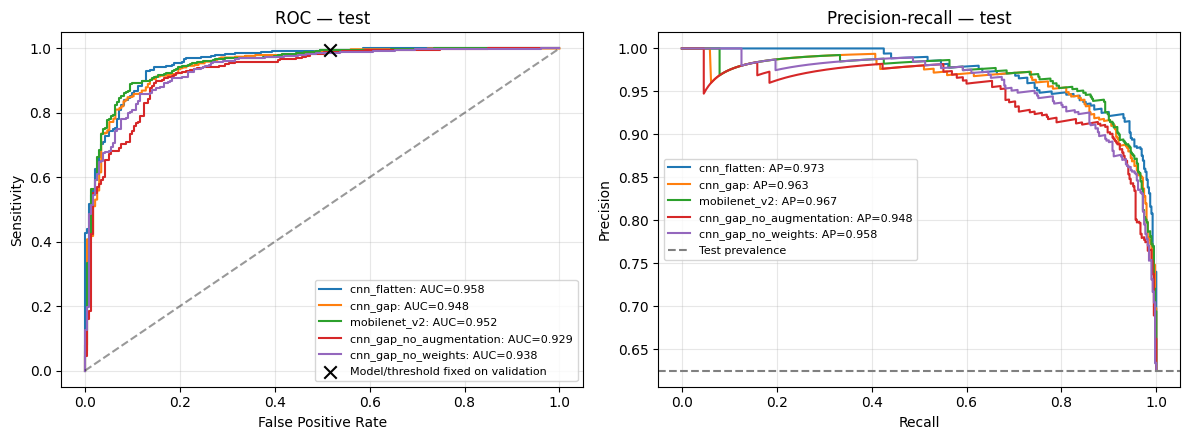

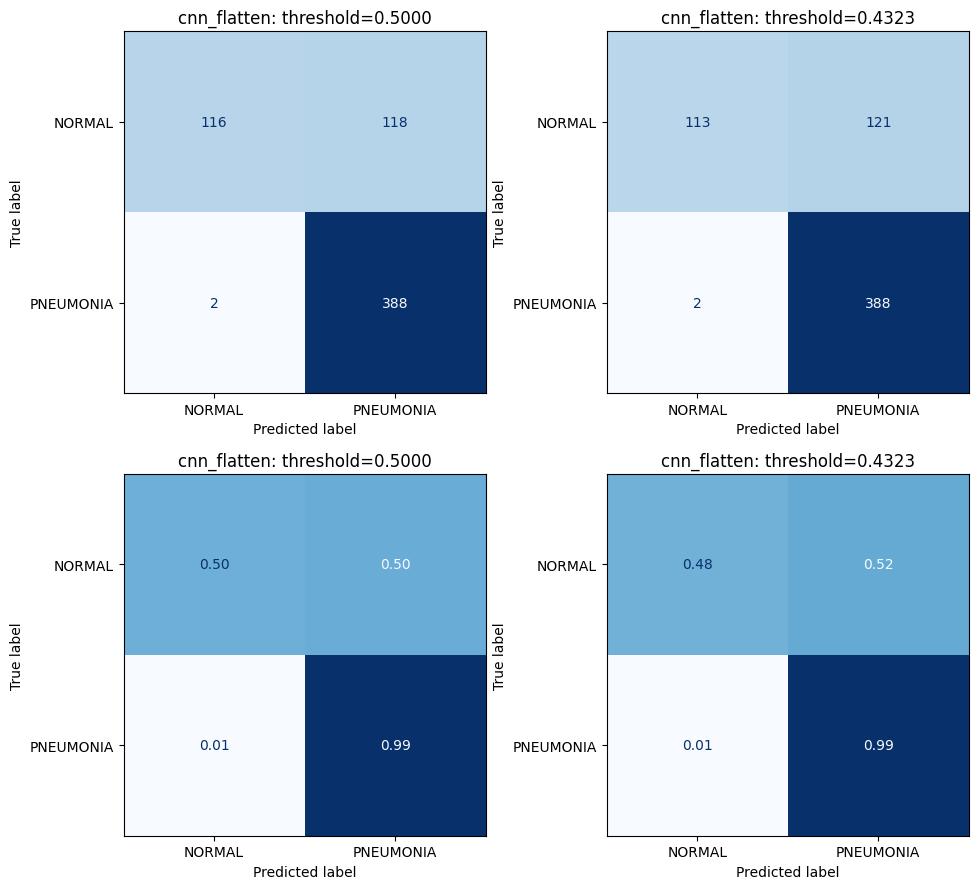

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, scores in test_scores.items():
    fpr, tpr, _ = roc_curve(test_df.label, scores)
    precision, recall, _ = precision_recall_curve(test_df.label, scores)
    axes[0].plot(fpr, tpr, label=f"{name}: AUC={roc_auc_score(test_df.label, scores):.3f}")
    axes[1].plot(recall, precision,
                 label=f"{name}: AP={average_precision_score(test_df.label, scores):.3f}")
point = metric_values(test_df.label, primary_scores, primary_threshold)
axes[0].scatter(1 - point["specificity"], point["sensitivity"], color="black", marker="x",
                s=80, label="Model/threshold fixed on validation", zorder=5)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].axhline(test_df.label.mean(), color="gray", linestyle="--", label="Test prevalence")
axes[0].set(xlabel="False Positive Rate", ylabel="Sensitivity", title="ROC — test")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall — test")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for col, threshold in enumerate([0.5, primary_threshold]):
    predicted = (primary_scores >= threshold).astype(int)
    for row, normalization in enumerate([None, "true"]):
        ConfusionMatrixDisplay.from_predictions(
            test_df.label, predicted, labels=[0, 1], display_labels=CLASS_NAMES,
            normalize=normalization, values_format="d" if row == 0 else ".2f",
            cmap="Blues", colorbar=False, ax=axes[row, col])
        axes[row, col].set_title(f"{PRIMARY_MODEL}: threshold={threshold:.4f}")
plt.tight_layout()
plt.show()

### Validation–test gap and component effects

We compare the **same restored model**, inference mode, and threshold across
the two partitions. Validation metrics are recomputed after restoring the
weights selected by early stopping. Differences may reflect validation-based
selection, sample composition, or image distribution; they do not, on their
own, establish overfitting or its cause.

The ablation table uses validation data only. Differences are estimates from
a single training run, not statistical evidence of superiority. The GAP variant
retains all other choices from the Flatten variant; different weight shapes
prevent identical initialization of the classifier head.

In [37]:
comparison = validation_results.query("operating_point == 'validation'").merge(
    test_results.query("operating_point == 'validation'"), on="model", suffixes=("_val", "_test"))
for metric in ["accuracy", "sensitivity", "specificity", "balanced_accuracy", "roc_auc"]:
    comparison[f"{metric}_gap_pp"] = 100 * (comparison[f"{metric}_val"] - comparison[f"{metric}_test"])
display(comparison[["model", "accuracy_val", "accuracy_test", "accuracy_gap_pp",
                    "sensitivity_gap_pp", "specificity_gap_pp", "roc_auc_gap_pp"]].round(3))
comparison.to_csv(ARTIFACT_DIR / "validation_test_comparison.csv", index=False)

val_fixed = validation_results.query("operating_point == '0.5'").set_index("model")
ablation_rows = []
for reference, variant, change in [
    ("cnn_flatten", "cnn_gap", "Flatten → GAP"),
    ("cnn_gap", "cnn_gap_no_augmentation", "Remove augmentation"),
    ("cnn_gap", "cnn_gap_no_weights", "Remove class weights"),
]:
    if reference in val_fixed.index and variant in val_fixed.index:
        ablation_rows.append({"comparison": change, "reference": reference, "variant": variant,
            **{f"delta_{metric}": val_fixed.loc[variant, metric] - val_fixed.loc[reference, metric]
               for metric in ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]}})
ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results.round(4))
ablation_results.to_csv(ARTIFACT_DIR / "validation_ablations.csv", index=False)

,model,accuracy_val,accuracy_test,accuracy_gap_pp,sensitivity_gap_pp,specificity_gap_pp,roc_auc_gap_pp
0,cnn_flatten,0.976,0.803,17.283,-1.402,47.978,3.811
1,cnn_gap,0.974,0.814,15.950,-0.633,42.958,4.644
2,mobilenet_v2,0.969,0.785,18.412,-1.402,50.440,4.359
3,cnn_gap_no_augmentation,0.961,0.734,22.695,-1.402,61.130,6.053
4,cnn_gap_no_weights,0.964,0.766,19.807,-1.145,53.275,5.314


,comparison,reference,variant,delta_roc_auc,delta_balanced_accuracy,delta_sensitivity,delta_specificity
0,Flatten → GAP,cnn_flatten,cnn_gap,-0.0013,-0.0075,0.0000,-0.0149
1,Remove augmentation,cnn_gap,cnn_gap_no_augmentation,-0.0050,-0.0127,-0.0029,-0.0224
2,Remove class weights,cnn_gap,cnn_gap_no_weights,-0.0035,-0.0100,-0.0088,-0.0112


<a id="conclusions"></a>
## 9. Error analysis and conclusions

We display the primary model's false positives and false negatives, ordered by
scores furthest from the correct decision. This is a descriptive analysis, not
a new selection criterion. If it suggests model changes, those changes will
require a further protocol and independent confirmation data.

The images may suggest checks involving quality, borders, text, padding, or
acquisition differences. Visual inspection alone does not establish which
features the network used and does not justify correcting clinical diagnoses.

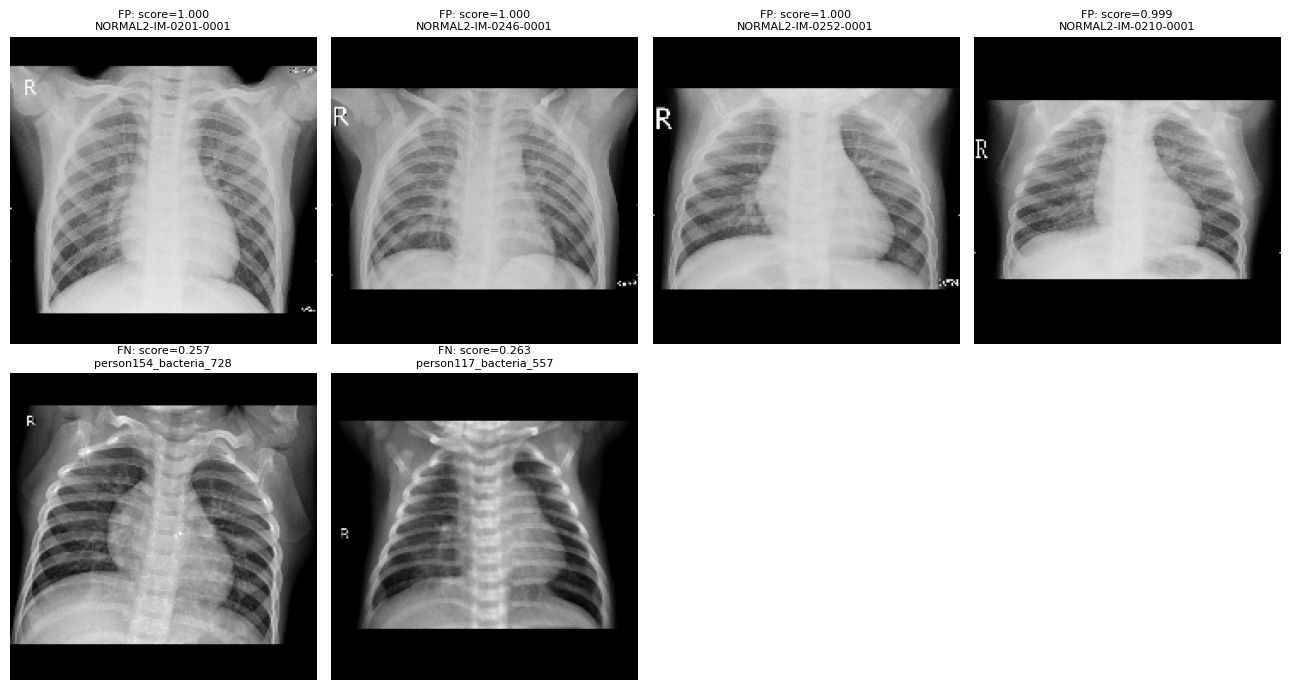

In [38]:
errors = test_df.copy()
errors["score"] = primary_scores
errors["predicted"] = (primary_scores >= primary_threshold).astype(int)
errors["error_type"] = np.select(
    [errors.label.eq(0) & errors.predicted.eq(1),
     errors.label.eq(1) & errors.predicted.eq(0)], ["FP", "FN"], default="correct")
errors.to_csv(ARTIFACT_DIR / "primary_model_errors.csv", index=False)
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for row, error_type in enumerate(["FP", "FN"]):
    selected = errors[errors.error_type.eq(error_type)].sort_values(
        "score", ascending=(error_type == "FN")).head(4)
    for ax in axes[row]:
        ax.axis("off")
    if selected.empty:
        axes[row, 0].text(0.1, 0.5, f"No {error_type}", transform=axes[row, 0].transAxes)
    for ax, (_, example) in zip(axes[row], selected.iterrows()):
        image, _ = read_image(example.path, example.label)
        ax.imshow(image.numpy().squeeze(), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{error_type}: score={example.score:.3f}\n{Path(example.path).stem}", fontsize=8)
plt.tight_layout()
plt.show()

In [39]:
result = metric_values(test_df.label, primary_scores, primary_threshold)
default = metric_values(test_df.label, primary_scores, 0.5)
ci_recall = confidence_intervals.loc["sensitivity"]
ci_specificity = confidence_intervals.loc["specificity"]
constraint_text = ("met" if result["sensitivity"] >= TARGET_RECALL else "not met")
display(Markdown(f"""
### Computed results

The model selected on validation is **{PRIMARY_MODEL}**, with threshold
**{primary_threshold:.6f}**. On the test set, it achieves accuracy **{result['accuracy']:.1%}**,
balanced accuracy **{result['balanced_accuracy']:.1%}**, ROC-AUC **{result['roc_auc']:.3f}**
and average precision **{result['average_precision']:.3f}**.

Sensitivity is **{result['sensitivity']:.1%}** (95% bootstrap CI:
{ci_recall.lower_95:.1%}–{ci_recall.upper_95:.1%}); specificity is
**{result['specificity']:.1%}** (95% CI:
{ci_specificity.lower_95:.1%}–{ci_specificity.upper_95:.1%}).
The empirical recall constraint of {TARGET_RECALL:.0%}, imposed on validation,
is **{constraint_text} on the test set**.

Compared with a threshold of 0.5, false positives change from **{default['fp']}** to
**{result['fp']}**, and false negatives from **{default['fn']}** to **{result['fn']}**.
These counts describe the observed trade-off without automatically
assigning clinical utility to it.
"""))


### Computed results

The model selected on validation is **cnn_flatten**, with threshold
**0.432257**. On the test set, it achieves accuracy **80.3%**,
balanced accuracy **73.9%**, ROC-AUC **0.958**
and average precision **0.973**.

Sensitivity is **99.5%** (95% bootstrap CI:
98.6%–100.0%); specificity is
**48.3%** (95% CI:
42.4%–54.9%).
The empirical recall constraint of 98%, imposed on validation,
is **met on the test set**.

Compared with a threshold of 0.5, false positives change from **118** to
**121**, and false negatives from **2** to **2**.
These counts describe the observed trade-off without automatically
assigning clinical utility to it.


### Limitations and interpretation

- Group and duplicate checks can be inspected in the manifest, but filenames
  do not verify patient identity and near-duplicates have not been ruled out.
- A single seed does not measure training variability; bootstrap intervals
  do not include uncertainty in model or threshold selection.
- The evaluation is exploratory and limited to one dataset. No external
  validation is provided: applicability to other centers or populations
  requires independent data from different sources.
- Class weights balance the loss, whereas the threshold determines the final
  trade-off. Neither automatically calibrates the scores.
- Accuracy or recall alone does not establish clinical value: the context
  and errors require a dedicated assessment. The metrics do not establish
  readiness for autonomous diagnosis.
- The ablations estimate the effects of GAP, augmentation, and class weights
  under the described experimental conditions. Conclusions concern these
  configurations and must account for training variability.

### Technical references

- [Dataset and original description on Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
- [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [Decision threshold tuning](https://scikit-learn.org/stable/modules/classification_threshold.html)
- [MobileNetV2 and preprocessing](https://keras.io/api/applications/mobilenet/mobilenet_models/)
- [Transfer learning and BatchNormalization](https://keras.io/guides/transfer_learning/)